# Computer Vision Projekt

CAS Deep Learning FS26 - CV Projekt
26.6.2026 - Marco Buri

## Notizen

### Quellen
* https://www.nature.com/articles/s41597-023-02682-2
    * Sammlung verschiedener Datasets
    * Kombination aus Fotos und Renders
    * mit Bounding Boxes
* https://www.kaggle.com/datasets/joosthazelzet/lego-brick-images/data
    * keine Segmentierungsmasken, nur für Klassifikation möglich
* https://www.kaggle.com/datasets/dreamfactor/biggest-lego-dataset-600-parts/data
    * nur Renders
    * mit Bounding Boxes

### 29.5.26 - Besprechung mit Susanne
* Wenige Klassen verwenden (ca. 10)
* Klassifizierung würde für CV Projekt ausreichen
* Für Vertiefungsprojekt:
    * Nur Suche Anwenden basierend auf Object Detection würde nicht ausreichen, da gleiches Modell und nur Suche nach der Klasse (Lego Nr.)
    * Similarity anhand der Form/Farbe wäre aber möglich (Stichwort Latent Space)
        * Abfotografiertes Teil muss dann in Latent Space transformiert werden
        * Detektierte Objekte auf dem Suchbild (wo viele Teile liegen), müssen auch in Latent Space transformiert werden
    * Andere Idee: Für CV Projekt Object Detection basierend auf synthetischen Daten und dann im Vertiefungsprojekt eigenes Datenset erstellen mit neuen Klassen (dann Transfer Learning)

## Idee CV Projekt

* Objekterkennung mit ca. 10 Klassen gem. oben
* straight-forward umsetzbar

## Idee Vertiefungsprojekt

* Similarity Analyse im Latent Space
* Generalisierung -> unabhängig der gegebenen Klassen
* Ev. muss neues Modell trainiert werden oder fine-tuned Variante von oben kann wiederverwendet werden
* Gem. Vibe
    * 

## 1. Setup & Installation

In [1]:
%pip install -q kaggle pandas matplotlib pillow numpy tqdm


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Dataset Download

Dataset: [Largest LEGO Dataset (600 parts)](https://www.kaggle.com/datasets/dreamfactor/biggest-lego-dataset-600-parts)  
~8.35 GB of Blender-rendered images with YOLO-format bounding box annotations (168k images, 600 classes).

**Prerequisites:** Configure your Kaggle API token:
1. Go to kaggle.com → Account → Create API Token
2. Save the downloaded `kaggle.json` to `~/.kaggle/kaggle.json`
3. Run `chmod 600 ~/.kaggle/kaggle.json`

In [2]:
import os
import subprocess
import glob

DATASET_SLUG = "dreamfactor/biggest-lego-dataset-600-parts"
DATA_DIR = "data"
BASE_DIR = os.path.join(DATA_DIR, "dataset_20210629145407_top_600")

if not os.path.exists(BASE_DIR):
    print("Downloading dataset (~8.35 GB, may take several minutes)...")
    os.makedirs(DATA_DIR, exist_ok=True)
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", DATASET_SLUG, "-p", DATA_DIR, "--unzip"],
        check=True,
    )
    print("Download complete.")
else:
    print(f"Dataset found at: {os.path.abspath(BASE_DIR)}")

Dataset URL: https://www.kaggle.com/datasets/dreamfactor/biggest-lego-dataset-600-parts
License(s): CC0-1.0


100%|██████████| 7.68G/7.68G [04:31<00:00, 30.4MB/s]  



Download complete.


## 3. Dataset Structure

In [3]:
import os
import glob

# Auto-detect base directory in case the archive name differs
BASE_DIR = None
for entry in sorted(os.listdir("data")):
    path = os.path.join("data", entry)
    if os.path.isdir(path) and "lego" in entry.lower() or entry.startswith("dataset_"):
        BASE_DIR = path
        break
if BASE_DIR is None:
    # Fallback: use first subdirectory under data/
    subdirs = [os.path.join("data", d) for d in os.listdir("data") if os.path.isdir(os.path.join("data", d))]
    BASE_DIR = subdirs[0] if subdirs else "data"

print(f"Base directory: {os.path.abspath(BASE_DIR)}")
print("\nContents:")
for entry in sorted(os.listdir(BASE_DIR)):
    p = os.path.join(BASE_DIR, entry)
    if os.path.isdir(p):
        n = len(os.listdir(p))
        print(f"  {entry}/  ({n:,} files)")
    else:
        size = os.path.getsize(p) / 1024
        print(f"  {entry}  ({size:.1f} KB)")

ANN_DIR = os.path.join(BASE_DIR, "annotations")
IMG_DIR = os.path.join(BASE_DIR, "images")
ann_files = sorted(glob.glob(os.path.join(ANN_DIR, "*")))
img_files = sorted(glob.glob(os.path.join(IMG_DIR, "*")))

print(f"\nImages:      {len(img_files):,}")
print(f"Annotations: {len(ann_files):,}")

# Peek at one annotation file to identify format
if ann_files:
    sample_ann = ann_files[0]
    ext = os.path.splitext(sample_ann)[1]
    print(f"\nAnnotation extension: {ext}")
    with open(sample_ann) as f:
        content = f.read(300)
    print(f"Sample ({os.path.basename(sample_ann)}):\n{content}")

# Show sample image filenames
print("\nSample images:")
for f in img_files[:5]:
    print(f"  {os.path.basename(f)}")

Base directory: /Users/marco/repos/cas-deep-learning-cv-projekt/data/dataset_20210629145407_top_600

Contents:
  annotations/  (167,802 files)
  images/  (167,800 files)

Images:      167,800
Annotations: 167,802

Annotation extension: .xml
Sample (00002a86-e7ac-11eb-9d54-b0c090bd3910.xml):
<?xml version="1.0" ?>
<annotation>
    <folder>BrickRay</folder>
    <filename>00002a86-e7ac-11eb-9d54-b0c090bd3910.jpg</filename>
    <size>
        <width>300</width>
        <height>300</height>
        <depth>3</depth>
    </size>
    <object>
        <name>27263</name>
        <difficult>0</di

Sample images:
  00002a86-e7ac-11eb-9d54-b0c090bd3910.jpg
  00002cc0-e4b9-11eb-afd8-b0c090bd3910.jpg
  000120ae-e601-11eb-aaa1-b0c090bd3910.jpg
  00013d5a-e7b9-11eb-924a-b0c090bd3910.jpg
  00017dcc-e462-11eb-9a00-b0c090bd3910.jpg


## 4. Basic Data Analysis

Parse all YOLO-format annotation files into a DataFrame and compute summary statistics.

In [7]:
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm import tqdm

# ── Ensure path variables are set (re-derive if cell run standalone) ──────────
if "BASE_DIR" not in dir() or not BASE_DIR:
    for entry in sorted(os.listdir("data")):
        path = os.path.join("data", entry)
        if os.path.isdir(path) and ("lego" in entry.lower() or entry.startswith("dataset_")):
            BASE_DIR = path
            break

ANN_DIR = os.path.join(BASE_DIR, "annotations")
IMG_DIR = os.path.join(BASE_DIR, "images")
ann_files = sorted(glob.glob(os.path.join(ANN_DIR, "*.xml")))
img_files = sorted(glob.glob(os.path.join(IMG_DIR, "*")))

print(f"Annotation format: Pascal VOC XML")
print(f"Annotation files: {len(ann_files):,}")
print(f"Image files:      {len(img_files):,}")

# ── Parse Pascal VOC XML annotations ─────────────────────────────────────────
records = []
skipped = 0

for ann_path in tqdm(ann_files, desc="Parsing annotations", unit="file"):
    try:
        tree = ET.parse(ann_path)
    except ET.ParseError:
        skipped += 1
        continue

    root = tree.getroot()
    size = root.find("size")
    if size is None:
        skipped += 1
        continue

    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)
    img_name = os.path.splitext(
        root.findtext("filename", default=os.path.basename(ann_path))
    )[0]

    for obj in root.findall("object"):
        cls_name = obj.findtext("name", default="unknown")
        bndbox = obj.find("bndbox")
        if bndbox is None:
            continue
        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))
        bw = xmax - xmin
        bh = ymax - ymin
        records.append({
            "image": img_name,
            "class_name": cls_name,
            "img_width": img_w,
            "img_height": img_h,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "bbox_width": bw,
            "bbox_height": bh,
            "area_px": bw * bh,
            "area_norm": (bw * bh) / (img_w * img_h),
            "aspect_ratio": bw / bh if bh > 0 else 0,
            "x_center_norm": (xmin + bw / 2) / img_w,
            "y_center_norm": (ymin + bh / 2) / img_h,
        })

df = pd.DataFrame(records)

# Assign integer class IDs from sorted unique names
classes = sorted(df["class_name"].unique())
class_to_id = {c: i for i, c in enumerate(classes)}
df["class_id"] = df["class_name"].map(class_to_id)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  Total images:          {len(img_files):>10,}")
print(f"  Images with labels:    {df['image'].nunique():>10,}")
print(f"  Total bounding boxes:  {len(df):>10,}")
print(f"  Unique classes:        {df['class_name'].nunique():>10,}")
print(f"  Avg boxes per image:   {len(df)/df['image'].nunique():>10.1f}")
if skipped:
    print(f"  Skipped (malformed):   {skipped:>10,}")
print(f"{'='*45}")

df.head(10)

Annotation format: Pascal VOC XML
Annotation files: 167,802
Image files:      167,800


Parsing annotations: 100%|██████████| 167802/167802 [00:11<00:00, 15197.61file/s]



  Total images:             167,800
  Images with labels:       167,801
  Total bounding boxes:     551,204
  Unique classes:               574
  Avg boxes per image:          3.3
  Skipped (malformed):            1


,image,class_name,img_width,img_height,xmin,ymin,xmax,ymax,bbox_width,bbox_height,area_px,area_norm,aspect_ratio,x_center_norm,y_center_norm,class_id
0,00002a86-e7ac-11eb-9d54-b0c090bd3910,27263,300,300,122,124,299,296,177,172,30444,0.338267,1.029070,0.701667,0.700000,145
1,00002a86-e7ac-11eb-9d54-b0c090bd3910,30374,300,300,0,12,143,232,143,220,31460,0.349556,0.650000,0.238333,0.406667,200
2,00002cc0-e4b9-11eb-afd8-b0c090bd3910,3023,600,600,0,77,59,169,59,92,5428,0.015078,0.641304,0.049167,0.205000,184
3,00002cc0-e4b9-11eb-afd8-b0c090bd3910,32140,600,600,212,41,397,137,185,96,17760,0.049333,1.927083,0.507500,0.148333,243
4,00002cc0-e4b9-11eb-afd8-b0c090bd3910,60471,600,600,481,431,600,550,119,119,14161,0.039336,1.000000,0.900833,0.817500,447
5,00002cc0-e4b9-11eb-afd8-b0c090bd3910,34103,600,600,348,371,441,538,93,167,15531,0.043142,0.556886,0.657500,0.757500,276
6,000120ae-e601-11eb-aaa1-b0c090bd3910,2736,300,300,0,26,221,138,221,112,24752,0.275022,1.973214,0.368333,0.273333,147
7,000120ae-e601-11eb-aaa1-b0c090bd3910,4589,300,300,120,81,300,270,180,189,34020,0.378000,0.952381,0.700000,0.585000,391
8,00013d5a-e7b9-11eb-924a-b0c090bd3910,42022,300,300,0,52,255,191,255,139,35445,0.393833,1.834532,0.425000,0.405000,358
9,00013d5a-e7b9-11eb-924a-b0c090bd3910,23443,300,300,245,170,300,239,55,69,3795,0.042167,0.797101,0.908333,0.681667,96


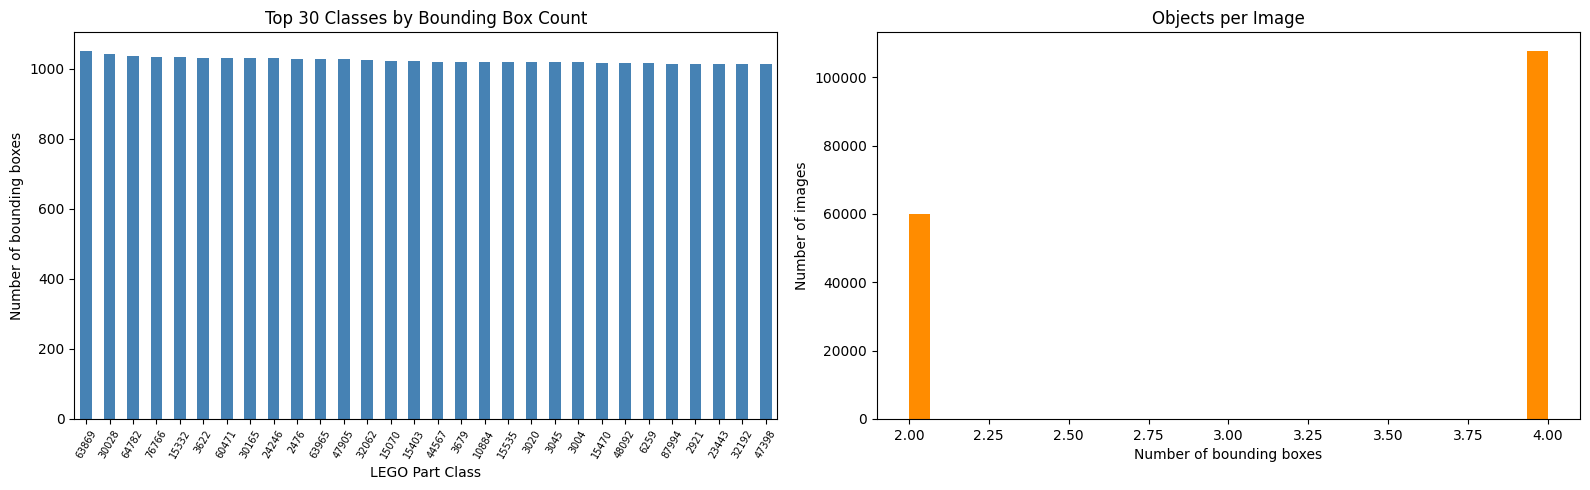

Min objects/image: 2
Max objects/image: 4
Mean objects/image: 3.28


In [8]:
import matplotlib.pyplot as plt

# ── 4a. Class distribution (top 30) ──────────────────────────────────────────
counts_per_class = df.groupby("class_name").size().sort_values(ascending=False)
top_n = 30

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts_per_class.head(top_n).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="none"
)
axes[0].set_title(f"Top {top_n} Classes by Bounding Box Count")
axes[0].set_xlabel("LEGO Part Class")
axes[0].set_ylabel("Number of bounding boxes")
axes[0].tick_params(axis="x", labelsize=7, rotation=60)

# Objects per image distribution
objs_per_img = df.groupby("image").size()
axes[1].hist(objs_per_img, bins=30, color="darkorange", edgecolor="none")
axes[1].set_title("Objects per Image")
axes[1].set_xlabel("Number of bounding boxes")
axes[1].set_ylabel("Number of images")

plt.tight_layout()
plt.show()

print(f"Min objects/image: {objs_per_img.min()}")
print(f"Max objects/image: {objs_per_img.max()}")
print(f"Mean objects/image: {objs_per_img.mean():.2f}")

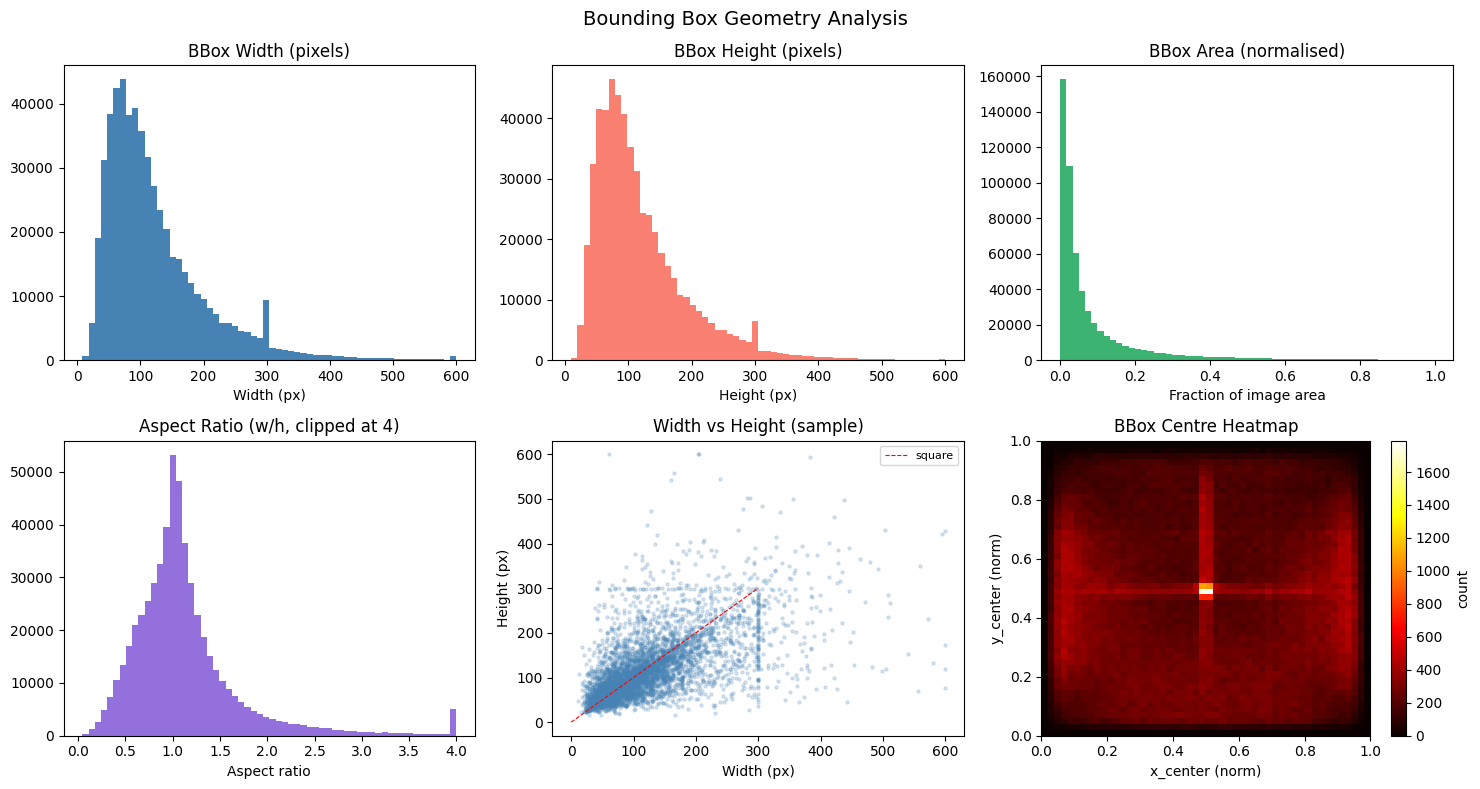


Bounding Box Statistics:
        bbox_width  bbox_height    area_norm  aspect_ratio
count  551204.0000  551204.0000  551204.0000   551204.0000
mean      123.7985     120.1575       0.0910        1.1445
std        81.4448      74.8823       0.1416        0.7012
min         8.0000      10.0000       0.0005        0.0429
25%        68.0000      68.0000       0.0150        0.7955
50%       101.0000     100.0000       0.0355        1.0261
75%       155.0000     151.0000       0.0983        1.2841
max       600.0000     600.0000       0.9967       22.6875


In [9]:
import numpy as np

# ── 4b. Bounding box geometry statistics ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(df["bbox_width"], bins=60, color="steelblue", edgecolor="none")
axes[0, 0].set_title("BBox Width (pixels)")
axes[0, 0].set_xlabel("Width (px)")

axes[0, 1].hist(df["bbox_height"], bins=60, color="salmon", edgecolor="none")
axes[0, 1].set_title("BBox Height (pixels)")
axes[0, 1].set_xlabel("Height (px)")

axes[0, 2].hist(df["area_norm"], bins=60, color="mediumseagreen", edgecolor="none")
axes[0, 2].set_title("BBox Area (normalised)")
axes[0, 2].set_xlabel("Fraction of image area")

axes[1, 0].hist(
    df["aspect_ratio"].clip(0, 4), bins=60, color="mediumpurple", edgecolor="none"
)
axes[1, 0].set_title("Aspect Ratio (w/h, clipped at 4)")
axes[1, 0].set_xlabel("Aspect ratio")

# Width vs Height scatter (random sample for speed)
sample = df.sample(min(5000, len(df)), random_state=42)
axes[1, 1].scatter(sample["bbox_width"], sample["bbox_height"], alpha=0.2, s=5, color="steelblue")
axes[1, 1].set_title("Width vs Height (sample)")
axes[1, 1].set_xlabel("Width (px)")
axes[1, 1].set_ylabel("Height (px)")
axes[1, 1].plot([0, 300], [0, 300], "r--", linewidth=0.8, label="square")
axes[1, 1].legend(fontsize=8)

# BBox centre heatmap
h2d, xedges, yedges = np.histogram2d(
    df["x_center_norm"], df["y_center_norm"], bins=50, range=[[0, 1], [0, 1]]
)
im = axes[1, 2].imshow(
    h2d.T, origin="lower", aspect="auto",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap="hot",
)
axes[1, 2].set_title("BBox Centre Heatmap")
axes[1, 2].set_xlabel("x_center (norm)")
axes[1, 2].set_ylabel("y_center (norm)")
plt.colorbar(im, ax=axes[1, 2], label="count")

plt.suptitle("Bounding Box Geometry Analysis", fontsize=14)
plt.tight_layout()
plt.show()

print("\nBounding Box Statistics:")
print(df[["bbox_width", "bbox_height", "area_norm", "aspect_ratio"]].describe().round(4))

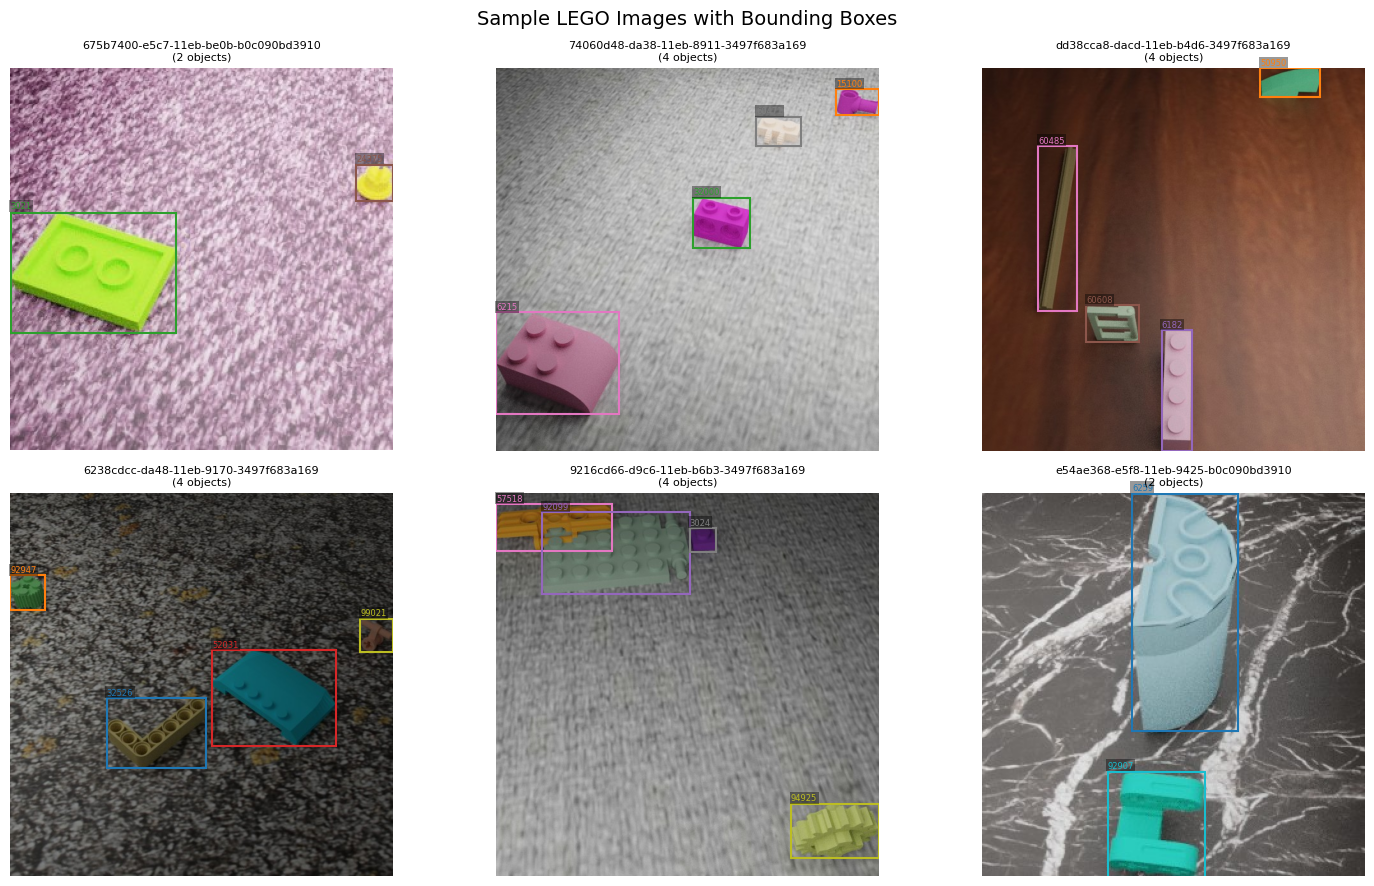

In [10]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# ── 4c. Sample images with bounding boxes ────────────────────────────────────
N_SAMPLES = 6
COLORS = plt.cm.tab10.colors

sample_images = random.sample(df["image"].unique().tolist(), N_SAMPLES)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, img_name in zip(axes.flatten(), sample_images):
    img_path = None
    for ext in (".jpg", ".jpeg", ".png"):
        p = os.path.join(IMG_DIR, img_name + ext)
        if os.path.exists(p):
            img_path = p
            break

    if img_path is None:
        ax.axis("off")
        ax.set_title(f"{img_name}\n(image not found)")
        continue

    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")

    anns = df[df["image"] == img_name]
    for _, row in anns.iterrows():
        color = COLORS[row["class_id"] % len(COLORS)]
        # Pascal VOC: coordinates are already in absolute pixels
        rect = patches.Rectangle(
            (row["xmin"], row["ymin"]),
            row["bbox_width"],
            row["bbox_height"],
            linewidth=1.5, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            row["xmin"], row["ymin"] - 2, row["class_name"],
            color=color, fontsize=6, va="bottom",
            bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"),
        )

    ax.set_title(
        f"{img_name}\n({len(anns)} object{'s' if len(anns) != 1 else ''})",
        fontsize=8,
    )

plt.suptitle("Sample LEGO Images with Bounding Boxes", fontsize=14)
plt.tight_layout()
plt.show()